In [2]:
#Q:21
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("accuracy ",accuracy_score(y_test,y_pred))

accuracy  1.0


In [3]:
#Q:22
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

x,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsRegressor(n_neighbors=5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("mean squared error:", mse)

mean squared error: 108.14198878074414


In [6]:
#Q:23
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model1 = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
model1.fit(x_train,y_train)
y_pred1 = model1.predict(x_test)
accu1 = accuracy_score(y_test,y_pred1)

model2 = KNeighborsClassifier(n_neighbors=5,metric='manhattan')
model2.fit(x_train,y_train)
y_pred2 = model2.predict(x_test)
accu2 = accuracy_score(y_test,y_pred2)

print("accuracy with euclidean:",accu1)
print("accuracy with manhattan:",accu2)


accuracy with euclidean: 1.0
accuracy with manhattan: 1.0


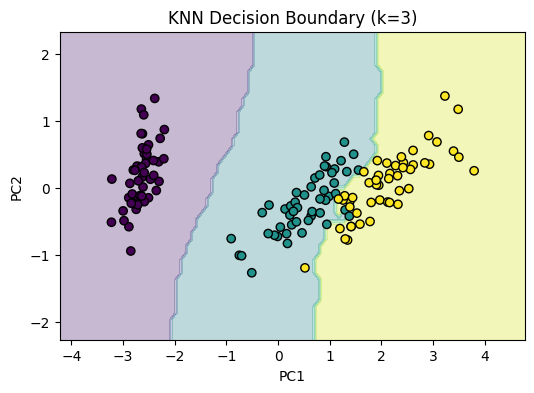

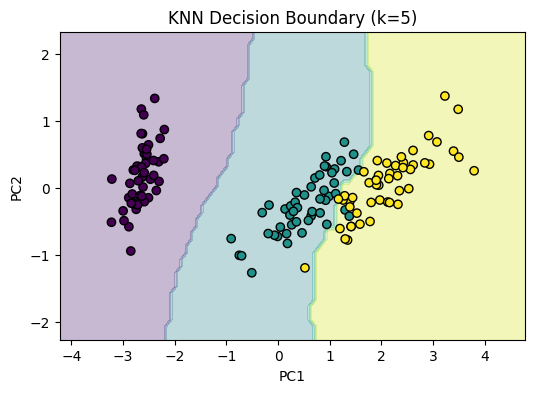

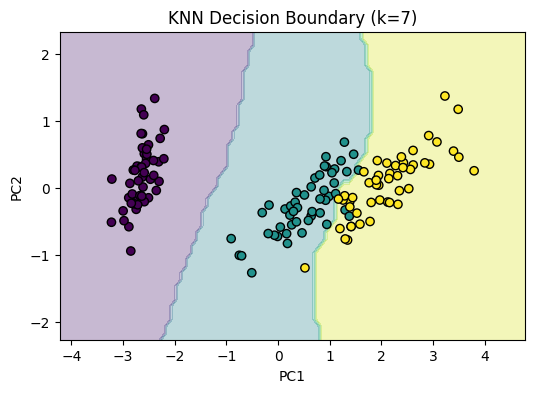

In [13]:
#Q:24
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Load and reduce to 2D with PCA so decision boundary can be plotted
x,y = load_iris(return_X_y=True)
pca = PCA(n_components=2)
x2 = pca.fit_transform(x)

x_train,x_test,y_train,y_test = train_test_split(x2,y,test_size=0.2,random_state=42)

k_values = [3,5,7]
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)

    x_min,x_max = x2[:,0].min()-1, x2[:,0].max()+1
    y_min,y_max = x2[:,1].min()-1, x2[:,1].max()+1

    xx,yy = np.meshgrid(np.arange(x_min,x_max,0.1), np.arange(y_min,y_max,0.1))

    z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    plt.figure(figsize=(6,4))
    plt.contourf(xx,yy,z,alpha=0.3)
    plt.scatter(x2[:,0], x2[:,1], c=y, edgecolor='k')
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()



In [ ]:
#Q:25
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


#model with scaling
scaler  = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(x_train_scaled,y_train)
y_pred1 = model1.predict(x_test_scaled)
accu1 = accuracy_score(y_test,y_pred1)

#model without scaling 
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(x_train,y_train)
y_pred2 = model2.predict(x_test)
accu2 = accuracy_score(y_test,y_pred2)

print(f'accuracy with feature scaling:{accu1}')
print(f'accuracy without feature scaling:{accu2}')


accuracy with feature scaling:1.0
accuracy without feature scaling:1.0


In [16]:
#Q:26
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
x,y =make_classification(n_samples=100,n_features=10,n_informative=5,n_redundant=2,n_classes=3,random_state=42)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

print("explained variation ratio:\n",pca.explained_variance_ratio_)

explained variation ratio:
 [0.42007229 0.13840308]


In [19]:
#Q:27
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#model without pca
model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(x_train,y_train)
y_pred1 = model1.predict(x_test)
accu1 = accuracy_score(y_test,y_pred1)

#model with pca
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(x_train_pca,y_train)
y_pred2 = model2.predict(x_test_pca)
accu2 = accuracy_score(y_test,y_pred2)

print(f'accuracy without PCA:{accu1}')
print(f'accuracy with PCA:{accu2}')

accuracy without PCA:1.0
accuracy with PCA:1.0


In [ ]:
#Q:28
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier()
param_grid = {'n_neighbors':[3,4,5,7,8],'metric':['euclidean','manhattan'],'weights':['uniform','distance']}
grid_search = GridSearchCV(estimator=model,param_grid=param_grid,cv=5)
grid_search.fit(x_train,y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
best_param = grid_search.best_params_

print(f'best parameters:{best_param}')
print(f'best model accuracy: {accuracy}')

best parameters:{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
best model accuracy: 1.0


In [22]:
#Q:29
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


x,y = make_classification(n_samples=100,n_features=10,n_redundant=2,n_classes=2,n_informative=2,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
misclassified = (y_test != y_pred).sum()
print(f'number of misclassified samples: {misclassified}')
          

number of misclassified samples: 0


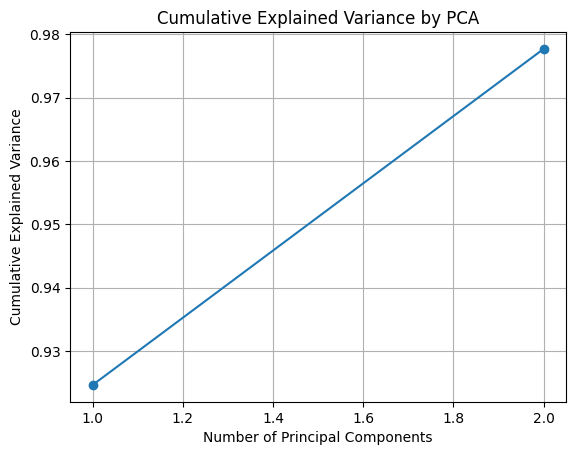

In [ ]:
#Q:30
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

x,y = load_iris(return_X_y=True)
pca = PCA(n_components=2)
pca.fit(x)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

#vizualise
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA')
plt.grid(True)
plt.show()

In [ ]:
#Q:31
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

weights_options = ['uniform','distance']
for w in weights_options:
    knn = KNeighborsClassifier(n_neighbors=5,weights=w)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)

    print(f'weights: {w}', f'accuracy: {accuracy}')

weights: uniform accuracy: 1.0
weights: distance accuracy: 1.0


In [ ]:
#Q:32
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

x,y = make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

k_values = [3,5,7]
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f'k:{k}', f'mean squared error: {mse}')

k:3 mean squared error: 128.82204336272395
k:5 mean squared error: 108.14198878074414
k:7 mean squared error: 101.49093206922446


In [ ]:
#Q:33
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

data = {
    'A':[1,2,np.nan,4,5],
    'B':[5,np.nan,7,8,9],
    'c':[2,3,4,np.nan,8]
}

df = pd.DataFrame(data)
print(df)

imputer = KNNImputer(n_neighbors=2)
df_imputer = imputer.fit_transform(df)
print('\nDataFrame after KNN imputation:\n',df_imputer)

     A    B    c
0  1.0  5.0  2.0
1  2.0  NaN  3.0
2  NaN  7.0  4.0
3  4.0  8.0  NaN
4  5.0  9.0  8.0

DataFrame after KNN imputation:
 [[1. 5. 2.]
 [2. 6. 3.]
 [3. 7. 4.]
 [4. 8. 6.]
 [5. 9. 8.]]


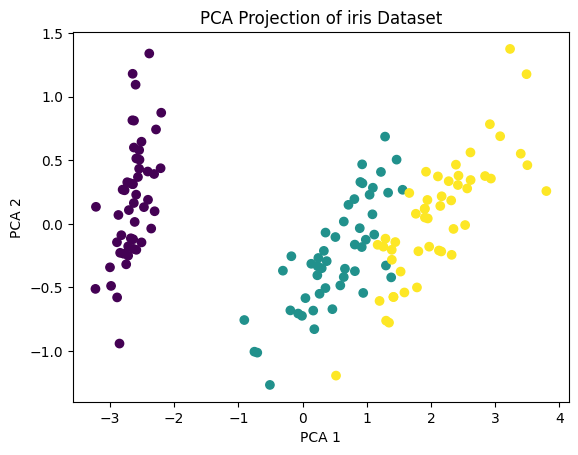

In [30]:
#Q:34
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

data = load_iris()
x = data.data
y = data.target

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
#plot projected data
plt.scatter(x_pca[:,0],x_pca[:,1],c=y)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection of iris Dataset")
plt.show()


In [ ]:
#Q:35
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=24)

#kd tree algorithm
kd_model = KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree')
kd_model.fit(x_train,y_train)
kd_pred = kd_model.predict(x_test)
kd_accuracy = accuracy_score(y_test,kd_pred)

#ball tree algorithm
ball_model = KNeighborsClassifier(n_neighbors=5,algorithm='ball_tree')
ball_model.fit(x_train,y_train)
ball_pred = ball_model.predict(x_test)
ball_accuracy = accuracy_score(y_test,ball_pred)

print(f'kd tree accuracy: {kd_accuracy}')
print(f'ball tree accuracy:{ball_accuracy}')


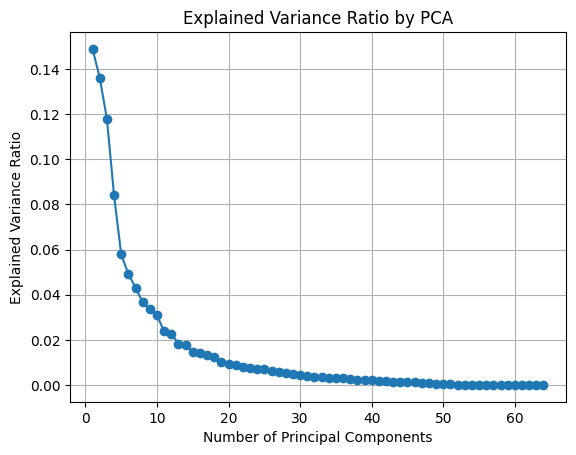

In [31]:
#Q:36
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = load_digits()
x = data.data
pca = PCA()
pca.fit(x)

plt.plot(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_,marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by PCA')
plt.grid(True)
plt.show()

In [ ]:
#Q:37
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,f1_score,recall_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
precision = precision_score(y_test,y_pred,average='macro')
f1 = f1_score(y_test,y_pred,average='macro')
recall = recall_score(y_test,y_pred,average='macro')
print(f'precision: {precision}, f1 score: {f1}, recall: {recall}')

precision: 1.0, f1 score: 1.0, recall: 1.0


In [35]:
#Q:38
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_digits(return_X_y=True)
components = [2,4,5,6,8,7]
for n in components:
    pca = PCA(n_components=n)
    x_pca = pca.fit_transform(x)
    x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42)

    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    print('component_pca:',n,'accuracy score:',accuracy)

component_pca: 2 accuracy score: 0.6111111111111112
component_pca: 4 accuracy score: 0.8805555555555555
component_pca: 5 accuracy score: 0.9416666666666667
component_pca: 6 accuracy score: 0.9472222222222222
component_pca: 8 accuracy score: 0.9638888888888889
component_pca: 7 accuracy score: 0.9638888888888889


In [36]:
#Q:39
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
leaf_sizes = [10,20,30,40,50]
for l in leaf_sizes:
    model = KNeighborsClassifier(n_neighbors=5,leaf_size=l)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)

    print(f'leaf_size:{l} accuracy score{accuracy}')

leaf_size:10 accuracy score0.9861111111111112
leaf_size:20 accuracy score0.9861111111111112
leaf_size:30 accuracy score0.9861111111111112
leaf_size:40 accuracy score0.9861111111111112
leaf_size:50 accuracy score0.9861111111111112


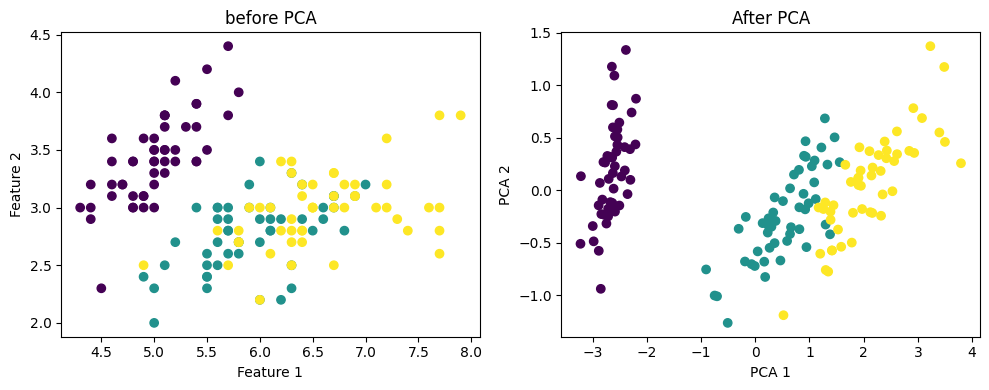

In [ ]:
#Q:40
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

x,y = load_iris(return_X_y=True)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

#before pca
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(x[:,0],x[:,1],c=y)
plt.title("before PCA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

#After pca
plt.subplot(1,2,2)
plt.scatter(x_pca[:,0],x_pca[:,1],c=y)
plt.title("After PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

In [39]:
#Q:41
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

x,y = load_wine(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
knnc = KNeighborsClassifier(n_neighbors=5)
knnc.fit(x_train,y_train)
y_pred = knnc.predict(x_test)
classi_report = classification_report(y_test,y_pred)
print("classification report:",classi_report)

classification report:               precision    recall  f1-score   support

           0       0.86      0.86      0.86        14
           1       0.79      0.79      0.79        14
           2       0.38      0.38      0.38         8

    accuracy                           0.72        36
   macro avg       0.67      0.67      0.67        36
weighted avg       0.72      0.72      0.72        36



In [41]:
#Q:42
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

x,y = fetch_california_housing(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
metrics = ['euclidean','manhattan','chebyshev','minkowski']

print("Prediction error using Different Distance Metrics\n")

for d in metrics:
    model = KNeighborsRegressor(n_neighbors=5,metric=d)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)

    print(f'{d.capitalize()} Distance ')
    print(f"MSE : {mse:.4f}")
    print(f"RMSE:{mse:.4f}")
    print("-" * 35)


Prediction error using Different Distance Metrics

Euclidean Distance 
MSE : 1.1187
RMSE:1.1187
-----------------------------------
Manhattan Distance 
MSE : 0.9945
RMSE:0.9945
-----------------------------------
Chebyshev Distance 
MSE : 1.1910
RMSE:1.1910
-----------------------------------
Minkowski Distance 
MSE : 1.1187
RMSE:1.1187
-----------------------------------


AUC score: 0.9959056665574845


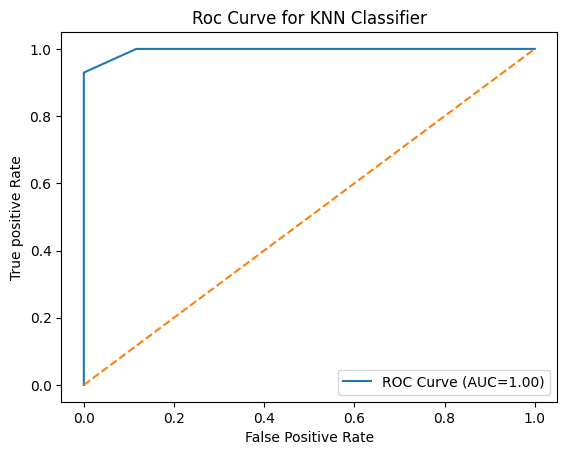

In [ ]:
#Q:43
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt

x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_prob = model.predict_proba(x_test)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

print("AUC score:",roc_auc)

#ploting
plt.plot(fpr,tpr,label="ROC Curve (AUC=%0.2f)" % roc_auc)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True positive Rate")
plt.title("Roc Curve for KNN Classifier")
plt.legend()
plt.show()


variance capture by each component:

PC1:0.3620


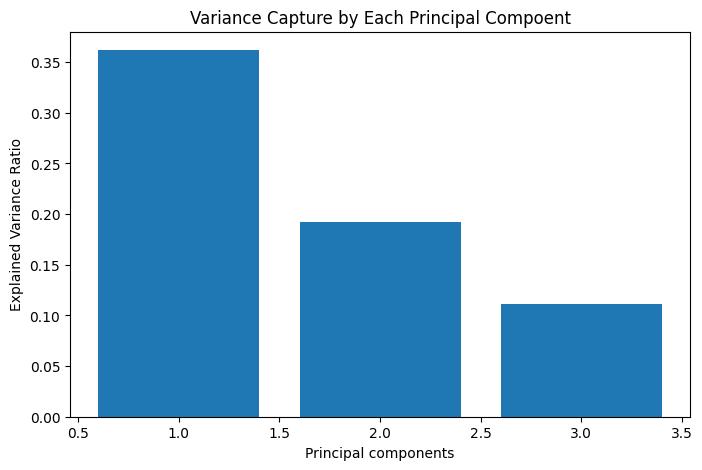

PC2:0.1921


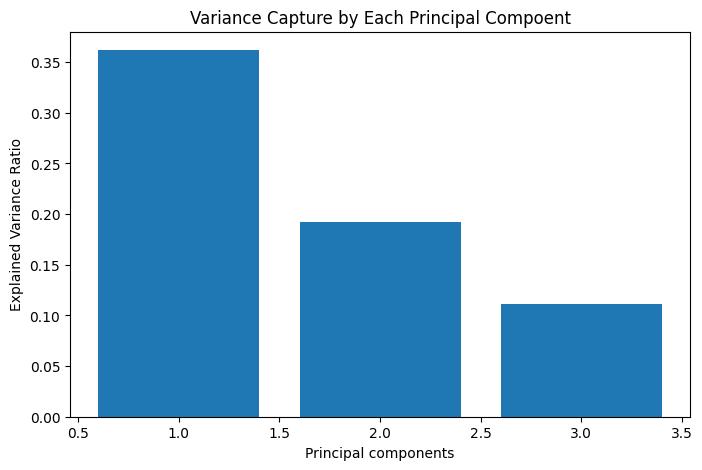

PC3:0.1112


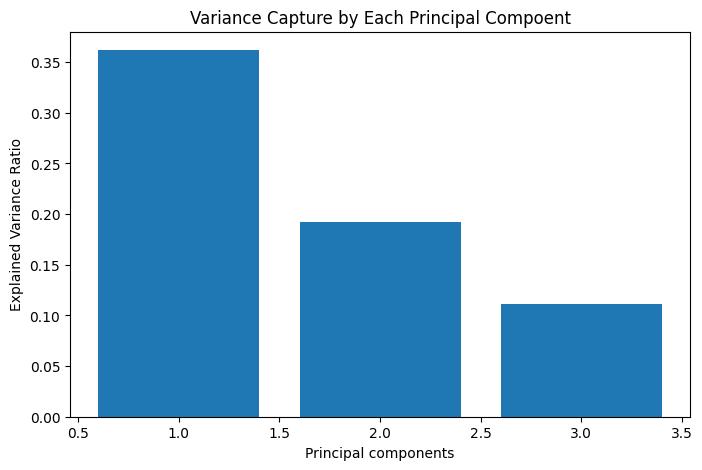

In [47]:
#Q:44
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA  
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

x,y = load_wine(return_X_y=True)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

variance = pca.explained_variance_ratio_

print("variance capture by each component:\n")

for i,var in enumerate(variance):
    print(f"PC{i+1}:{var:.4f}")

    plt.figure(figsize=(8,5))
    plt.bar(range(1,len(variance)+1),variance)
    plt.xlabel("Principal components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Variance Capture by Each Principal Compoent")
    plt.show()

In [49]:
#Q:45
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x,y = load_breast_cancer(return_X_y=True)
selector = SelectKBest(score_func=f_classif,k=10)
x_selected = selector.fit_transform(x,y)

x_train,x_test,y_train,y_test = train_test_split(x_selected,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
y_pred =model.predict(x_test)
accuarcy = accuracy_score(y_test,y_pred)
print("Accuarcy:",accuracy)

Accuarcy: 0.9861111111111112


Reconstructed error 0.4459366164306473


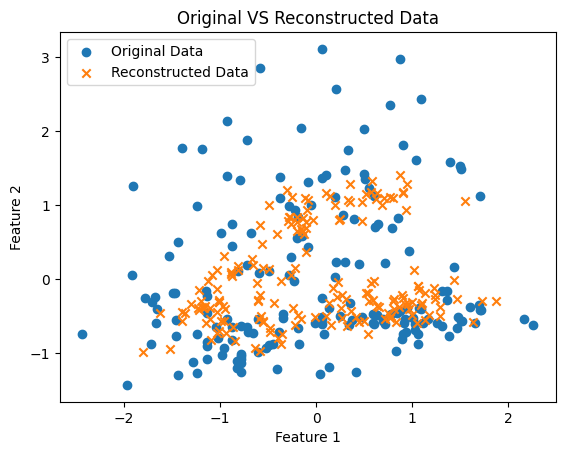

In [5]:
#Q:46
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

x,y = load_wine(return_X_y=True)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

x_reconstructed = pca.inverse_transform(x_pca)

error = mean_squared_error(x_scaled,x_reconstructed)
print("Reconstructed error", error)

plt.scatter(x_scaled[:,0],x_scaled[:,1],label="Original Data",marker='o')
plt.scatter(x_reconstructed[:,0],x_reconstructed[:,1],label="Reconstructed Data",marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original VS Reconstructed Data")
plt.legend()
plt.show()

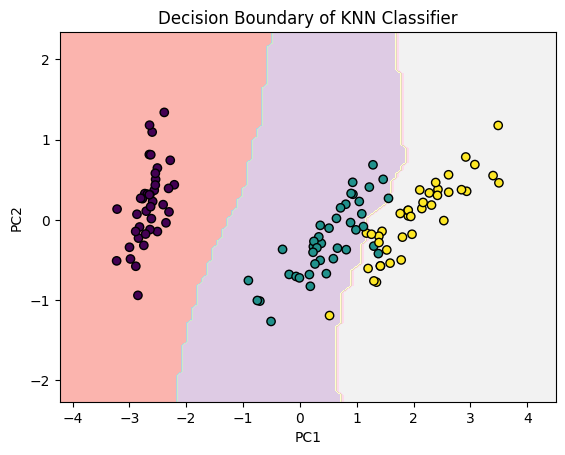

In [8]:
#Q:47
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

x,y = load_iris(return_X_y=True)

# Apply PCA to reduce to 2 dimensions for plotting
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

DecisionBoundaryDisplay.from_estimator(model,x_train,response_method="predict",cmap=plt.cm.Pastel1,xlabel="PC1",ylabel="PC2")
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,edgecolor="k")
plt.title("Decision Boundary of KNN Classifier" )
plt.show()

Cumulative Variance
1 Components : 0.3620
2 Components : 0.5541
3 Components : 0.6653
4 Components : 0.7360
5 Components : 0.8016
6 Components : 0.8510
7 Components : 0.8934
8 Components : 0.9202
9 Components : 0.9424
10 Components : 0.9617
11 Components : 0.9791
12 Components : 0.9920
13 Components : 1.0000


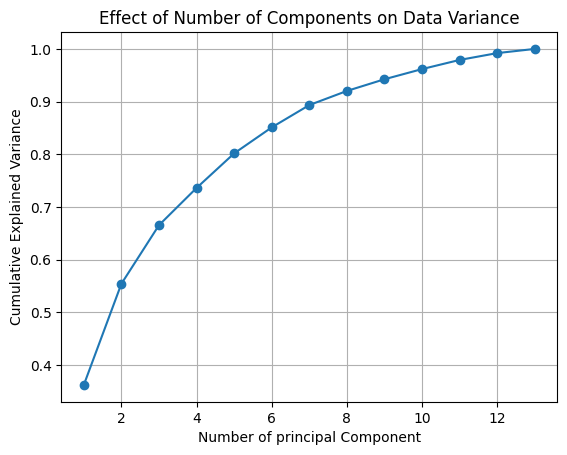

In [12]:
#Q:48
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
x,y  = load_wine(return_X_y=True)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
pca = PCA()
pca.fit(x_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Variance")
for i,var in enumerate(cumulative_variance):
    print(f"{i+1} Components : {var:.4f}")

plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker='o')
plt.xlabel("Number of principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Effect of Number of Components on Data Variance")
plt.grid(True)
plt.show()